# Module 3: Bilevel Problems

## <span style="color:darkblue">*From competitive markets equilibrium to Stackelberg games*</span>

We consider a simplified diesel market between 3 refineries. Each firm optimizes its own profit, subject only to a production capacity constraint. The firms have different efficiencies, represented by different marginal costs of production. Each player is maximizing their profit (minimising costs minus revenues):

\begin{align}
    \min_{x_i} \ & c_i x_i - p(x) x_i \\
    \text{s.t. } & x_i - X^{max}_i && \leq 0 \quad :\mu_i^{max} \\
    & - x_i && \leq 0 \\
\end{align}

where $p(x)$ is the market price.

In this exercise we investigate <span style="color:orange">**market-price formation**</span> and the <span style="color:orange">**production allocation**</span> in different market setups:

1)  Perfect competition  & Welfare maximization

2)  Cournot competition

3)  Generalized Nash equilibrium

4)  Stackelberg game

#### Activate the course environment and import packages

In [1]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using JuMP, Ipopt, PATHSolver, SCIP, Plots, DataFrames

  Activating project at `~/Library/CloudStorage/OneDrive-AaltoUniversity/Teaching/Berlin equilibrium course/Equilibrium_modeling_course_Berlin2026`


#### Problem data

In [2]:
# Marginal costs
c1 = 3
c2 = 4
c3 = 5

# Production capacities
X1_max = 3
X2_max = 4
X3_max = 2

# Demand function parameters
a = 10
b = 1

1

**Inverse demand curve**

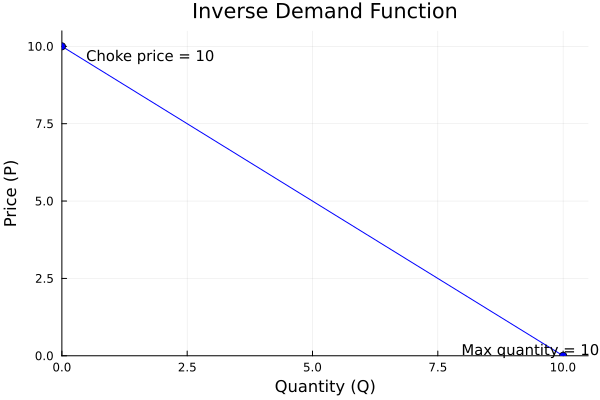

In [3]:
function plot_inverse_demand(; end_points=false, p=nothing)
    Q = range(0, a/b, length=100)
    P = a .- b .* Q

    if p === nothing
        p = plot(size=(600, 400))
    end

    plot!(p, Q, P, color=:blue, linewidth=1, label=false,
          xlabel="Quantity (Q)", ylabel="Price (P)", title="Inverse Demand Function", titlefontsize=14)

    if end_points
        scatter!(p, [0, a/b], [a, 0], color=:blue, markersize=4, label=false)
        annotate!(p, 0.5, a - 0.3, text("Choke price = $a", 10, :left))
        annotate!(p, a/b - 2, 0.2, text("Max quantity = $(a/b)", 10, :left))
    end

    xlims!(p, 0, a/b + 0.5)
    ylims!(p, 0, a + 0.5)

    return p
end

# Call the function to create and display the inverse demand curve
plot_inverse_demand(end_points=true)

#### Helper functions
The following functions are used to compute query market outcomes of the models, store results into a table and plot supply and demand curves.

In [4]:
function optimal_production(m)
    return [round(value(m[:x][i]), digits=2) for i in 1:3]
end

function market_price(m; round_value=true)
    x = [value(m[:x][i]) for i in 1:3]
    price = a - b*sum(x)
    return round_value ? round(price, digits=2) : price
end

function market_share(m)
    x = [value(m[:x][i]) for i in 1:3]
    total_x = sum(x)
    if total_x == 0
        return [0.0, 0.0, 0.0]
    else
        return [round(xi / total_x, digits=2) for xi in x]
    end
end

function optimal_profits(m)
    p = market_price(m, round_value=false)
    c = Dict(1 => c1, 2 => c2, 3 => c3)
    profits = Float64[]
    for i in 1:3
        profit = p * value(m[:x][i]) - c[i] * value(m[:x][i])
        profit = max(0, profit)  # avoids -0.0 values (all profits are positive in these models)
        push!(profits, round(profit, digits=2))
    end
    return profits
end

function social_welfare(m)
    x = [value(m[:x][i]) for i in 1:3]
    welfare = a*sum(x) - b/2*sum(x)^2 - (c1*x[1] + c2*x[2] + c3*x[3])
    return round(welfare, digits=2)
end

function add_results_to_table!(table, m, setup)
    # Skip if this setup is already in the table
    if nrow(table) > 0 && setup in table.Setup
        return table
    end
    profits = optimal_profits(m)
    production = optimal_production(m)
    push!(table, (setup, market_price(m), production[1], production[2], production[3],
                   profits[1], profits[2], profits[3], social_welfare(m)))
    return table
end

add_results_to_table! (generic function with 1 method)

In [33]:
function supply_demand_plot(c1, c2, c3, X1_max, X2_max, X3_max; title="",
                            equilibrium_point=false, Q=0, P=0,
                            p=nothing, firm_labels=true, alpha=0.8)

    if p === nothing
        p = plot_inverse_demand(end_points=false)
    end

    # Create supply curves for each firm (marginal cost lines).
    # For perfectly competitive firms, supply is horizontal at marginal cost up to capacity.
    firms = [("Firm 1", c1, X1_max), ("Firm 2", c2, X2_max), ("Firm 3", c3, X3_max)]

    # Sort firms by marginal cost (lowest to highest)
    firms_sorted = sort(firms, by = f -> f[2])

    # Create aggregate supply curve as a step function
    supply_q = [0.0]
    supply_p = [0.0]
    cum_q = 0.0
    for (name, cost, capacity) in firms_sorted
        push!(supply_q, cum_q); push!(supply_p, cost)
        cum_q += capacity
        push!(supply_q, cum_q); push!(supply_p, cost)
    end
    push!(supply_q, cum_q); push!(supply_p, 20)  # extend supply curve upward

    plot!(p, supply_q, supply_p, seriestype=:steppost, color=:darkred, linewidth=2, alpha=alpha, label=false)

    if firm_labels
        cum_q = 0.0
        for (name, cost, capacity) in firms_sorted
            annotate!(p, cum_q + capacity/2, cost - 0.5, text(name, 8, :darkred))
            cum_q += capacity
        end
    end

    if equilibrium_point
        scatter!(p, [Q], [P], color=:black, markersize=4, label=false)
        annotate!(p, Q + 0.05, P + 0.3, text("($Q, $P)", 8, :left))
    end

    plot!(p, title=title, titlefontsize=14)
    xlims!(p, 0, max(a/b, X1_max + X2_max + X3_max) + 0.5)
    ylims!(p, 0, a + 0.5)

    return p
end

supply_demand_plot (generic function with 1 method)

Initialising the result table that will be filled throughout the exercises.

In [9]:
results_table = DataFrame(
    Setup = String[], Price = Float64[],
    Firm1_Production = Float64[], Firm2_Production = Float64[], Firm3_Production = Float64[],
    Firm1_Profit = Float64[], Firm2_Profit = Float64[], Firm3_Profit = Float64[],
    Welfare = Float64[]
)

results_table

Row,Setup,Price,Firm1_Production,Firm2_Production,Firm3_Production,Firm1_Profit,Firm2_Profit,Firm3_Profit,Welfare
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64


## Exercise 3.1 Perfect competition

### Task 1: Implementation of models

#### <span style="color:darkblue">Welfare-maximization model</span>

\begin{align*}
\text{Maximize}_{x_1, x_2, x_3} \quad
& \alpha \sum_{j=1}^{3} x_j
  - \frac{1}{2} \beta \left( \sum_{j=1}^{3} x_j \right)^2
  - \sum_{j=1}^{3} c_j x_j
\\
\text{s.t.} \quad
& x_i - X_i^{\max} \leq 0
    \qquad i = 1,2,3
\\
& -x_i \leq 0,
    \qquad i = 1,2,3.
\end{align*}

This is a standard quadratic program (QP), which can be solved with a standard **QP solver**. We will use **Ipopt**. It has an objective function, constraints and only primal variables.

In [10]:
function welfare_maximization_model(c1, c2, c3, X1_max, X2_max, X3_max)
    # Initialize model for welfare maximization (wm)
    wm = Model(Ipopt.Optimizer)
    set_silent(wm)

    # Set of firms
    I = [1, 2, 3]

    # Define parameters
    c = Dict(1 => c1, 2 => c2, 3 => c3)
    X_max = Dict(1 => X1_max, 2 => X2_max, 3 => X3_max)

    # Define nonnegative variables
    @variable(wm, x[I] >= 0)

    # Define objective function (social welfare maximization)
    @objective(wm, Max, a*sum(x[i] for i in I) - b/2*sum(x[i] for i in I)^2 - sum(c[i]*x[i] for i in I))

    # Define constraints (production capacities)
    @constraint(wm, [i in I], x[i] <= X_max[i])

    # Solve the model
    optimize!(wm)

    println("The solver found a ", termination_status(wm), " solution.")

    return wm
end

welfare_maximization_model (generic function with 1 method)

**Run model and query results**

In [11]:
welfare_model = welfare_maximization_model(c1, c2, c3, X1_max, X2_max, X3_max)
println("Market price: ", market_price(welfare_model))
println("Optimal production (x): ", optimal_production(welfare_model))
println("Optimal profits: ", optimal_profits(welfare_model))
println("Social welfare: ", social_welfare(welfare_model))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

The solver found a LOCALLY_SOLVED solution.
Market price: 4.0
Optimal production (x): [3.0, 3.0, -0.0]
Optimal profits: [3.0, 0.0, 0.0]
Social welfare: 21.0


The following cell adds the results to the results table.

In [12]:
add_results_to_table!(results_table, welfare_model, "Welfare Max")
results_table

Row,Setup,Price,Firm1_Production,Firm2_Production,Firm3_Production,Firm1_Profit,Firm2_Profit,Firm3_Profit,Welfare
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Welfare Max,4.0,3.0,3.0,-0.0,3.0,0.0,0.0,21.0


Visualise the supply and demand, identify welfare-maximizing equilibrium

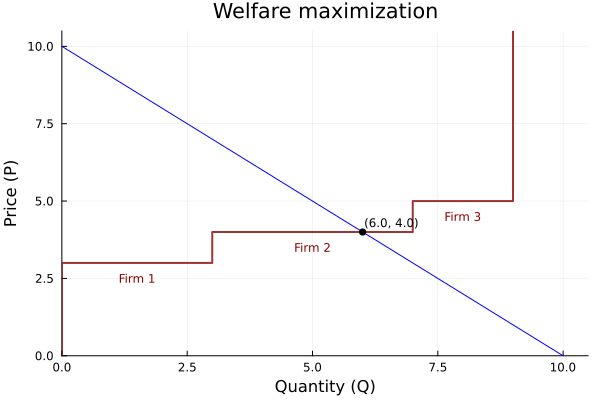

In [13]:
supply_demand_plot(c1, c2, c3, X1_max, X2_max, X3_max, title="Welfare maximization",
                   equilibrium_point=true, Q=sum(optimal_production(welfare_model)), P=market_price(welfare_model))

#### <span style="color:darkblue">Competitive-market model</span>
Note that this model models a perfect-competition Nash equilibrium.

\begin{align}
& 0 \leq x_i \perp c_i - \alpha + \beta \sum_j x_j + \mu_i^{\max} \geq 0, \quad \forall i \in \{1,2,3\}\\
& 0 \leq \mu_i^{\max} \perp X_i^{\max} - x_i  \geq 0, \quad \forall i \in \{1,2,3\}
\end{align}

This is a complementarity model, which does not have an objective function but is composed of **only complementarity conditions**. Solving it requires using the **PATH solver**, which employs a specific algorithm for this type of problem. In Julia, we use **JuMP** together with **PATHSolver.jl** and the `⟂` operator to formulate the complementarity constraints.

In [14]:
function competitive_market_model(c1, c2, c3, X1_max, X2_max, X3_max)
    # Initialize competitive market model (m)
    m = Model(PATHSolver.Optimizer)
    set_silent(m)

    # Set of firms
    I = [1, 2, 3]

    # Define parameters
    c = Dict(1 => c1, 2 => c2, 3 => c3)
    X_max = Dict(1 => X1_max, 2 => X2_max, 3 => X3_max)

    # Define variables
    @variable(m, x[I] >= 0)
    @variable(m, mu[I] >= 0)  # Dual variables

    # Complementarity constraints
    # 0 ≤ x_i ⟂ (c_i - a + b*sum(x_j) + mu_i) ≥ 0
    @constraint(m, [i in I], c[i] - a + b*sum(x[j] for j in I) + mu[i] ⟂ x[i])

    # 0 ≤ mu_i ⟂ (X_max_i - x_i) ≥ 0
    @constraint(m, [i in I], X_max[i] - x[i] ⟂ mu[i])

    # Solve the model using the PATH solver
    optimize!(m)

    println("The solver found a ", termination_status(m), " solution.")

    return m
end

competitive_market_model (generic function with 1 method)

**Run model and query results**

In [15]:
competitive_model = competitive_market_model(c1, c2, c3, X1_max, X2_max, X3_max)
println("Market price: ", market_price(competitive_model))
println("Optimal production (x): ", optimal_production(competitive_model))
println("Optimal profits: ", optimal_profits(competitive_model))
println("Social welfare: ", social_welfare(competitive_model))

The solver found a LOCALLY_SOLVED solution.
Market price: 4.0
Optimal production (x): [3.0, 3.0, 0.0]
Optimal profits: [3.0, 0.0, 0.0]
Social welfare: 21.0


*Why is social welfare maximized with this competitive formulation?* Use table below to compare the results of the two models.

In [16]:
add_results_to_table!(results_table, competitive_model, "Competitive NE")
results_table

Row,Setup,Price,Firm1_Production,Firm2_Production,Firm3_Production,Firm1_Profit,Firm2_Profit,Firm3_Profit,Welfare
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Welfare Max,4.0,3.0,3.0,-0.0,3.0,0.0,0.0,21.0
2,Competitive NE,4.0,3.0,3.0,0.0,3.0,0.0,0.0,21.0


Visualise the demand and supply curves to see the market equilibrium

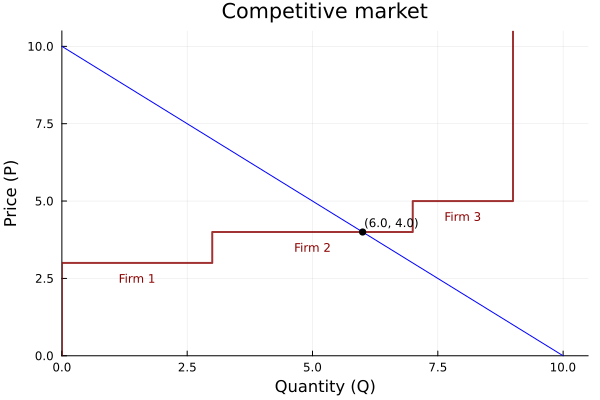

In [17]:
supply_demand_plot(c1, c2, c3, X1_max, X2_max, X3_max, title="Competitive market",
                   equilibrium_point=true, Q=sum(optimal_production(competitive_model)), P=market_price(competitive_model))

### Task 2: Sensitivity analysis

Change the costs of the firms so that firm 3 starts producing

In [18]:
# Change these values to see how the results change
c1_new = 3
c2_new = 4
c3_new = 5

cm_new = competitive_market_model(c1_new, c2_new, c3_new, X1_max, X2_max, X3_max)
println("Market price: ", market_price(cm_new))
println("Optimal production (x): ", optimal_production(cm_new))
println("Optimal profits: ", optimal_profits(cm_new))
println("Social welfare: ", social_welfare(cm_new))

## -- Uncomment the line below to plot the market-equilibrium with new costs
# supply_demand_plot(c1_new, c2_new, c3_new, X1_max, X2_max, X3_max,
#                     equilibrium_point=true, Q=sum(optimal_production(cm_new)), P=market_price(cm_new))

The solver found a LOCALLY_SOLVED solution.
Market price: 4.0
Optimal production (x): [3.0, 3.0, 0.0]
Optimal profits: [3.0, 0.0, 0.0]
Social welfare: 21.0


Increase the production capacities of the firms and observe the changes in the results.
 * Is there a change in the production allocation, if so why or why not?
 * How large would firm 1's capacity have to be for it to set the market price?

In [19]:
# Increase X_max values to see how the results change
X1_max_new = 3
X2_max_new = 4
X3_max_new = 2

cm_new = competitive_market_model(c1, c2, c3, X1_max_new, X2_max_new, X3_max_new)
println("Market price: ", market_price(cm_new))
println("Optimal production (x): ", optimal_production(cm_new))
println("Optimal profits: ", optimal_profits(cm_new))
println("Social welfare: ", social_welfare(cm_new))

## -- Uncomment the line below to plot the market-equilibrium with new capacities
# supply_demand_plot(c1, c2, c3, X1_max_new, X2_max_new, X3_max_new,
#                     equilibrium_point=true, Q=sum(optimal_production(cm_new)), P=market_price(cm_new))

The solver found a LOCALLY_SOLVED solution.
Market price: 4.0
Optimal production (x): [3.0, 3.0, 0.0]
Optimal profits: [3.0, 0.0, 0.0]
Social welfare: 21.0


## Exercise 3.2 Cournot competition

### Task 1: Implementation of model

#### <span style="color:darkblue">Cournot competition model</span>

\begin{align}
&0 \leq x_i \perp c_i + \beta x_i - \alpha + \beta \sum_{j} x_j + \mu_i^{\max} \geq 0, \quad i = 1, 2, 3\\
&0 \leq \mu_i^{\max} \perp X_i^{\max} - x_i  \geq 0, \quad i = 1, 2, 3
\end{align}

In [20]:
function cournot_market_model(c1, c2, c3, X1_max, X2_max, X3_max; print_status=true)
    # Initialize Cournot market model (m)
    m = Model(PATHSolver.Optimizer)
    set_silent(m)

    # Set of firms
    I = [1, 2, 3]

    # Define parameters
    c = Dict(1 => c1, 2 => c2, 3 => c3)
    X_max = Dict(1 => X1_max, 2 => X2_max, 3 => X3_max)

    # Define variables
    @variable(m, x[I] >= 0)
    @variable(m, mu[I] >= 0)  # Dual variables

    # Complementarity constraints
    # 0 ≤ x_i ⟂ (c_i + b*x_i - a + b*sum(x_j) + mu_i) ≥ 0
    @constraint(m, [i in I], c[i] + b*x[i] - a + b*sum(x[j] for j in I) + mu[i] ⟂ x[i])

    # 0 ≤ mu_i ⟂ (X_max_i - x_i) ≥ 0
    @constraint(m, [i in I], X_max[i] - x[i] ⟂ mu[i])

    # Solve the model using the PATH solver
    optimize!(m)

    if print_status
        println("The solver found a ", termination_status(m), " solution.")
    end

    return m
end

cournot_market_model (generic function with 1 method)

In [21]:
cournot_model = cournot_market_model(c1, c2, c3, X1_max, X2_max, X3_max)
println("Market price: ", market_price(cournot_model))
println("Optimal production (x): ", optimal_production(cournot_model))
println("Optimal profits: ", optimal_profits(cournot_model))
println("Social welfare: ", social_welfare(cournot_model))

The solver found a LOCALLY_SOLVED solution.
Market price: 5.5
Optimal production (x): [2.5, 1.5, 0.5]
Optimal profits: [6.25, 2.25, 0.25]
Social welfare: 18.88


*What do you notice about the ordering of the profits by firm?  Does this make sense?  If so, why?* Observe profits from table below.

In [22]:
add_results_to_table!(results_table, cournot_model, "Cournot NE")
results_table

Row,Setup,Price,Firm1_Production,Firm2_Production,Firm3_Production,Firm1_Profit,Firm2_Profit,Firm3_Profit,Welfare
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Welfare Max,4.0,3.0,3.0,-0.0,3.0,0.0,0.0,21.0
2,Competitive NE,4.0,3.0,3.0,0.0,3.0,0.0,0.0,21.0
3,Cournot NE,5.5,2.5,1.5,0.5,6.25,2.25,0.25,18.88


Illustrate the Cournot market outcome versus the competitive market in a plot

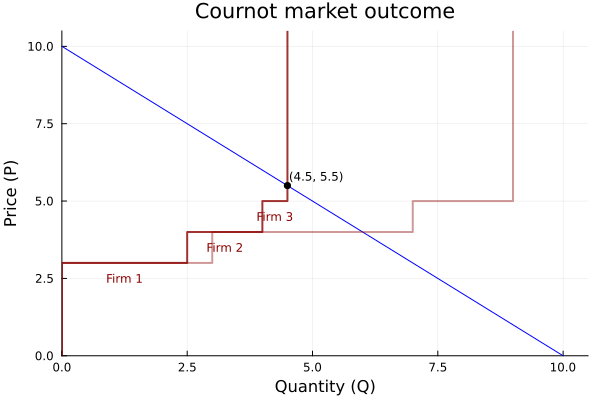

In [23]:
# Find optimal production quantities
q = optimal_production(cournot_model)

# Plot competitive supply curve
p = supply_demand_plot(c1, c2, c3, X1_max, X2_max, X3_max, firm_labels=false, alpha=0.4)

# Plot Cournot supply curve
supply_demand_plot(c1, c2, c3, q[1], q[2], q[3], title="Cournot market outcome",
                    equilibrium_point=true, Q=sum(q), P=market_price(cournot_model), p=p)

### Task 2

Investigate the effect of increasing production capacities

In [24]:
# Change X_max values so that a firm is able to fulfill maximum demand
X1_max_new = 3
X2_max_new = 4
X3_max_new = 2

# Run the Cournot model with new capacities
cournot_new = cournot_market_model(c1, c2, c3, X1_max_new, X2_max_new, X3_max_new)

# Print the results
println("Market price: ", market_price(cournot_new))
println("Optimal production (x): ", optimal_production(cournot_new))
println("Optimal profits: ", optimal_profits(cournot_new))
println("Social welfare: ", social_welfare(cournot_new))

# Uncomment the lines below to plot the Cournot market-equilibrium with new capacities
# q = optimal_production(cournot_new)
# supply_demand_plot(c1, c2, c3, q[1], q[2], q[3],
#                     equilibrium_point=true, Q=sum(q), P=market_price(cournot_new))

The solver found a LOCALLY_SOLVED solution.
Market price: 5.5
Optimal production (x): [2.5, 1.5, 0.5]
Optimal profits: [6.25, 2.25, 0.25]
Social welfare: 18.88


Investigate the effect of changing firm 1's costs and plot how the **profit** and **market share** change

In the next cell you can test different values for `c1_new` to see how the result changes for a specific value. In the following cell, you can run the results for multiple values for `c1_new` in a loop to see how the results change and then plot the results.

In [25]:
# Try different values for c1
c1_new = 3

# Run the Cournot model with new capacities
cournot_new = cournot_market_model(c1_new, c2, c3, X1_max, X2_max, X3_max)

# Print the results
println("Market price: ", market_price(cournot_new))
println("Optimal production (x): ", optimal_production(cournot_new))
println("Optimal profits: ", optimal_profits(cournot_new))
println("Social welfare: ", social_welfare(cournot_new))

# Uncomment the lines below to plot the Cournot market-equilibrium with new costs
# q = optimal_production(cournot_new)
# supply_demand_plot(c1_new, c2, c3, q[1], q[2], q[3],
#                     equilibrium_point=true, Q=sum(q), P=market_price(cournot_new))

The solver found a LOCALLY_SOLVED solution.
Market price: 5.5
Optimal production (x): [2.5, 1.5, 0.5]
Optimal profits: [6.25, 2.25, 0.25]
Social welfare: 18.88


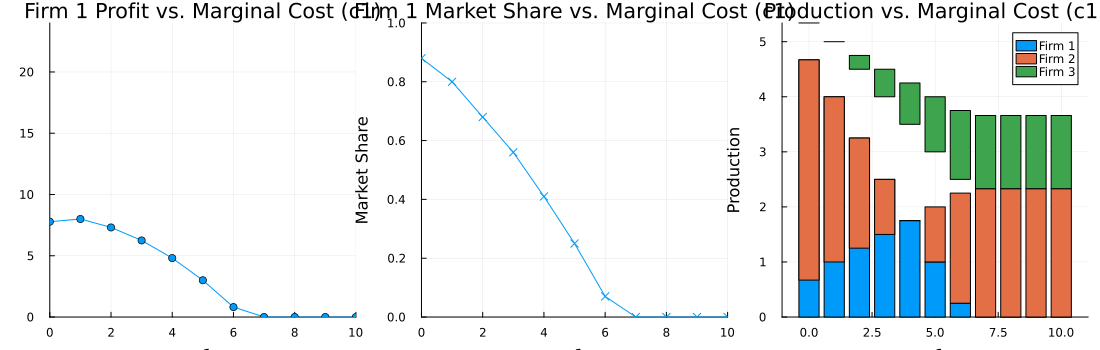

In [26]:
# Try a set of different values for c1
c1_new = collect(0:10)

# With X = 10, a firm is able to fulfill maximum demand
X1_max_new = 10
X2_max_new = 10
X3_max_new = 10

# -- RUN THE RESULTS -- #
profits1 = Float64[]
market_shares1 = Float64[]
market_prices1 = Float64[]
quantities1 = Vector{Float64}[]

for c in c1_new
    cournot_new = cournot_market_model(c, c2, c3, X1_max_new, X2_max_new, X3_max_new, print_status=false)

    push!(profits1, optimal_profits(cournot_new)[1])
    push!(market_shares1, market_share(cournot_new)[1])
    push!(market_prices1, market_price(cournot_new))
    push!(quantities1, optimal_production(cournot_new))
end

# -- PLOT THE RESULTS -- #
Q1 = hcat(quantities1...)'  # rows = c1 values, columns = firms

p1 = plot(c1_new, profits1, marker=:circle, label=false,
          title="Firm 1 Profit vs. Marginal Cost (c1)", xlabel="c1", ylabel="Profit",
          xlims=(0,10), ylims=(0,24))

p2 = plot(c1_new, market_shares1, marker=:xcross, label=false,
          title="Firm 1 Market Share vs. Marginal Cost (c1)", xlabel="c1", ylabel="Market Share",
          xlims=(0,10), ylims=(0,1))

p3 = bar(c1_new, Q1[:,1], label="Firm 1", bar_width=0.8)
bar!(p3, c1_new, Q1[:,2], fillrange=Q1[:,1], label="Firm 2", bar_width=0.8)
bar!(p3, c1_new, Q1[:,1].+Q1[:,2].+Q1[:,3], fillrange=Q1[:,1].+Q1[:,2], label="Firm 3", bar_width=0.8)
plot!(p3, title="Production vs. Marginal Cost (c1)", xlabel="c1", ylabel="Production")

plot(p1, p2, p3, layout=(1,3), size=(1100, 350))

## Exercise 3.3 Generalized Nash equilibrium

### Task 1: Implementation

#### <span style="color:darkblue">Generalized Nash equilibrium model</span>

\begin{align}
&0 \leq x_i \perp c_i + \beta x_i - \alpha + \beta \sum_j x_j + \mu_i^{\max} + \delta_i \geq 0, \quad i = 1,2,3\\
&0 \leq \mu_i^{\max} \perp X_i^{\max} - x_i \geq 0, \quad i = 1,2,3 \\
&0 \leq \delta_i \perp X^{\text{total}} - \sum_i x_i  \geq 0
\end{align}

Notice that the dual variables $\delta_i$, must have equal values in the solution. In the implementation, we can ensure this either by defining a constraint $$\delta_1 = \delta_2 = \delta_3,$$ or by simply modelling the variables with **a single variable $\delta$** and using this variable in all of the players' problems. In this implementation, we use a single variable $\delta$.

In [27]:
function GNE_market_model(c1, c2, c3, X1_max, X2_max, X3_max, X_total; print_status=false)
    # Initialize GNE market model (m)
    m = Model(PATHSolver.Optimizer)
    set_silent(m)

    # Set of firms
    I = [1, 2, 3]

    # Define parameters
    c = Dict(1 => c1, 2 => c2, 3 => c3)
    X_max = Dict(1 => X1_max, 2 => X2_max, 3 => X3_max)

    # Define variables
    @variable(m, x[I] >= 0)
    @variable(m, mu[I] >= 0)     # Dual variables
    @variable(m, delta >= 0)     # New dual variable for GNE - one shared among firms

    # Complementarity constraints
    # 0 ≤ x_i ⟂ (c_i + b*x_i - a + b*sum(x_j) + mu_i + delta) ≥ 0
    @constraint(m, [i in I], c[i] + b*x[i] - a + b*sum(x[j] for j in I) + mu[i] + delta ⟂ x[i])

    # 0 ≤ mu_i ⟂ (X_max_i - x_i) ≥ 0
    @constraint(m, [i in I], X_max[i] - x[i] ⟂ mu[i])

    # GNE-specific constraint
    # 0 ≤ delta ⟂ X_total - sum(x_j) ≥ 0
    @constraint(m, X_total - sum(x[j] for j in I) ⟂ delta)

    # Solve the model using the PATH solver
    optimize!(m)

    if print_status
        println("The solver found a ", termination_status(m), " solution.")
    end

    return m
end

GNE_market_model (generic function with 1 method)

In [28]:
X_total = 4

GNE_model = GNE_market_model(c1, c2, c3, X1_max, X2_max, X3_max, X_total, print_status=true)
println("Market price: ", market_price(GNE_model))
println("Optimal production (x): ", optimal_production(GNE_model))
println("Optimal profits: ", optimal_profits(GNE_model))
println("Social welfare: ", social_welfare(GNE_model))

The solver found a LOCALLY_SOLVED solution.
Market price: 6.0
Optimal production (x): [2.33, 1.33, 0.33]
Optimal profits: [7.0, 2.67, 0.33]
Social welfare: 18.0


In [29]:
add_results_to_table!(results_table, GNE_model, "GNE")
results_table

Row,Setup,Price,Firm1_Production,Firm2_Production,Firm3_Production,Firm1_Profit,Firm2_Profit,Firm3_Profit,Welfare
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Welfare Max,4.0,3.0,3.0,-0.0,3.0,0.0,0.0,21.0
2,Competitive NE,4.0,3.0,3.0,0.0,3.0,0.0,0.0,21.0
3,Cournot NE,5.5,2.5,1.5,0.5,6.25,2.25,0.25,18.88
4,GNE,6.0,2.33,1.33,0.33,7.0,2.67,0.33,18.0


Illustrate the GNE market outcome versus the Cournot market in a plot

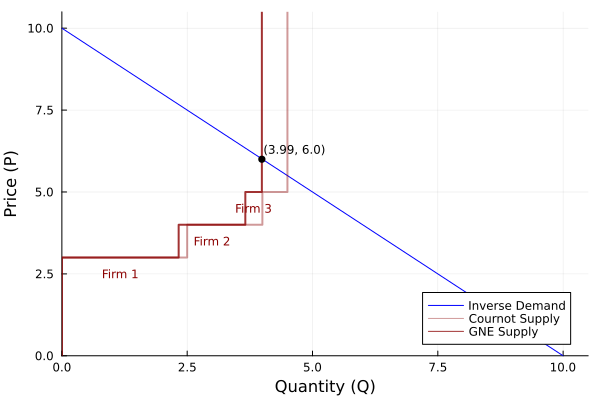

In [34]:
# Plot Cournot supply curve
q_cournot = optimal_production(cournot_model)
p = supply_demand_plot(c1, c2, c3, q_cournot[1], q_cournot[2], q_cournot[3], firm_labels=false, alpha=0.4)

# Plot GNE supply curve
q = optimal_production(GNE_model)
supply_demand_plot(c1, c2, c3, q[1], q[2], q[3],
                    equilibrium_point=true, Q=sum(q), P=market_price(GNE_model), p=p)

plot!(p, legend=:bottomright)
plot!(p, [], [], label="Inverse Demand", color=:blue)
plot!(p, [], [], label="Cournot Supply", color=:darkred, alpha=0.4)
plot!(p, [], [], label="GNE Supply", color=:darkred, alpha=0.8)

### Task 2: Vary cap on total supply

In the next cell, you can run the results for multiple values for `X_total` in a loop to see how the results change and then plot the results. For ease of analysis, remember that the marginal costs of the other firms are `c2 = 4` and `c3 = 5`.

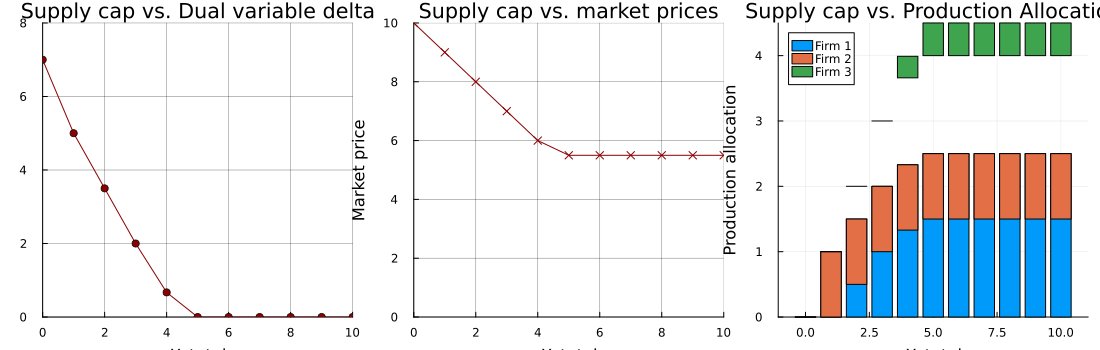

In [35]:
# Testing a set of different values for X_total
X_total_new = collect(0:10)

# -- RUN THE RESULTS -- #
delta_values_GNE = Float64[]
market_prices_GNE = Float64[]
quantities_GNE = Vector{Float64}[]

for X in X_total_new
    GNE_model_new = GNE_market_model(c1, c2, c3, X1_max, X2_max, X3_max, X)
    push!(delta_values_GNE, round(value(GNE_model_new[:delta]), digits=2))
    push!(market_prices_GNE, market_price(GNE_model_new))
    push!(quantities_GNE, optimal_production(GNE_model_new))
end

# -- PLOT THE RESULTS -- #
QG = hcat(quantities_GNE...)'

p1 = plot(X_total_new, delta_values_GNE, marker=:circle, color=:darkred, label=false,
          title="Supply cap vs. Dual variable delta", xlabel="X_total", ylabel="Dual variable delta",
          xlims=(0,10), ylims=(0,8), grid=true, gridalpha=0.5)

p2 = plot(X_total_new, market_prices_GNE, marker=:xcross, color=:darkred, label=false,
          title="Supply cap vs. market prices", xlabel="X_total", ylabel="Market price",
          xlims=(0,10), ylims=(0,10), grid=true, gridalpha=0.5)

p3 = bar(X_total_new, QG[:,1], label="Firm 1", bar_width=0.8)
bar!(p3, X_total_new, QG[:,2], fillrange=QG[:,1], label="Firm 2", bar_width=0.8)
bar!(p3, X_total_new, QG[:,1].+QG[:,2].+QG[:,3], fillrange=QG[:,1].+QG[:,2], label="Firm 3", bar_width=0.8)
plot!(p3, title="Supply cap vs. Production Allocation", xlabel="X_total", ylabel="Production allocation")

plot(p1, p2, p3, layout=(1,3), size=(1100, 350))

## Exercise 3.4 Stackelberg game

Here we assume a Stackelberg game where firm 1 is the leader and firms 2 and 3 are followers. The leader anticipates the reaction of the followers to its production decision. The lower-level problem is a Cournot market. The leader's problem can be formulated as a bilevel optimization problem:


\begin{align}
    \min_{x_1, x_2, x_3} \quad & c_1 x_1 - \left( \alpha - \beta \sum_{i=1}^{3} x_i \right) x_1 \\
    \text{s.t.} \quad & x_1 - X_1^{\max} \leq 0 \\
    & -x_1 \leq 0 \\
    & \text{Lower-level problem:} \nonumber \\
    &0 \leq x_i \perp c_i + \beta x_i - \alpha + \beta \sum_j x_j + \mu_i^{\max} \geq 0, \quad i = 2,3\\
    &0 \leq \mu_i^{\max} \perp X_i^{\max} - x_i \geq 0, \quad i = 2,3 \\
\end{align}

This model has several complexities: a  <span style="color:orange">**quadratic objective**</span> and <span style="color:orange">**complementarity constraints**</span>. The objective is <span style="color:orange">**convex**</span>. This type of problem cannot be implemented directly but requires reformulation.

### Task 1: Implementation of model with SOS1 variable reformulation

#### SOS1 variable transformation

In the special ordered sets 1 (SOS1) variable transformation, a complementarity constraint of the form $$0 \leq x \perp F(x) \geq 0$$ is reformulated and results in the following constraints:

\begin{align*}
    &2 (v^+ + v^-) = x + F(x) \\
    & 2 (v^+ - v^-) = x - F(x) \\
    & F(x) \geq 0 \\
    & v^+, v^- \text{ are SOS1} \\
    & v^+, v^-, x \geq 0 \\
\end{align*}

 To solve this, we need a solver that can handle <span style="color:orange">**quadratic programs (QP) with SOS1 variables**</span>. We will use the open-source solver **SCIP**.

The following function implements the SOS1 variable transformation into model `m` for a variable `var` and an expression `fun_expr` representing $F(var)$.

In [36]:
function sos1_variable_transformation(m::Model, var, fun_expr, name::String)
    # Adding SOS1 variables to the model
    vp = @variable(m, base_name = "vp_" * name, lower_bound = 0)
    vm = @variable(m, base_name = "vm_" * name, lower_bound = 0)

    # Add constraints to the model
    @constraint(m, fun_expr >= 0)
    @constraint(m, 2*(vp + vm) == var + fun_expr)
    @constraint(m, 2*(vp - vm) == var - fun_expr)

    # SOS1 constraint: at most one of vp, vm can be nonzero.
    # Weights are mandatory to specify; they may affect solver performance
    # but are set naively here.
    @constraint(m, [vp, vm] in MOI.SOS1([1.0, 2.0]))

    return vp, vm
end

sos1_variable_transformation (generic function with 1 method)

For ease of reading the code, the leader's problem is repeated here:

\begin{align}
    \min_{x_1, x_2, x_3} \quad & c_1 x_1 - \left( \alpha - \beta \sum_{i=1}^{3} x_i \right) x_1 \\
    \text{s.t.} \quad & x_1 - X_1^{\max} \leq 0 \\
    & -x_1 \leq 0 \\
    & \text{Lower-level problem:} \nonumber \\
    &0 \leq x_i \perp c_i + \beta x_i - \alpha + \beta \sum_j x_j + \mu_i^{\max} \geq 0, \quad i = 2,3\\
    &0 \leq \mu_i^{\max} \perp X_i^{\max} - x_i \geq 0, \quad i = 2,3 \\
\end{align}

In [37]:
function MPEC_firm1_leader_model(c1, c2, c3, X1_max, X2_max, X3_max)
    # Initialize MPEC market model (m)
    m = Model(SCIP.Optimizer)
    set_silent(m)

    # Set of firms
    I = [1, 2, 3]

    # Define parameters
    c = Dict(1 => c1, 2 => c2, 3 => c3)
    X_max = Dict(1 => X1_max, 2 => X2_max, 3 => X3_max)

    # Define variables
    @variable(m, x[I] >= 0)
    @variable(m, mu[I] >= 0)  # Dual variables

    # Objective function for firm 1 (leader): minimize negative profit
    @objective(m, Min, c[1]*x[1] - (a - b*sum(x[j] for j in I))*x[1])

    # Primal constraint for leader firm 1
    @constraint(m, x[1] <= X_max[1])

    # Complementarity constraints for firms 2 and 3 (followers), via SOS1 reformulation
    # 0 ≤ x_i ⟂ c_i + b*x_i - a + b*sum(x_j) + mu_i ≥ 0 for i = 2, 3
    for i in [2, 3]
        fx = c[i] + b*x[i] - a + b*sum(x[j] for j in I) + mu[i]
        sos1_variable_transformation(m, x[i], fx, "x$i")

        # 0 ≤ mu_i ⟂ (X_max_i - x_i) ≥ 0 for i = 2, 3
        fmu = X_max[i] - x[i]
        sos1_variable_transformation(m, mu[i], fmu, "mu$i")
    end

    # Solve the model using the SCIP solver
    optimize!(m)

    println("The solver found a ", termination_status(m), " solution.")

    return m
end

MPEC_firm1_leader_model (generic function with 1 method)

In [38]:
mpec_model = MPEC_firm1_leader_model(c1, c2, c3, X1_max, X2_max, X3_max)
println("Market price: ", market_price(mpec_model))
println("Optimal production (x): ", optimal_production(mpec_model))
println("Optimal profits: ", optimal_profits(mpec_model))
println("Social welfare: ", social_welfare(mpec_model))

The solver found a OPTIMAL solution.
Market price: 5.33
Optimal production (x): [3.0, 1.33, 0.33]
Optimal profits: [7.0, 1.78, 0.11]
Social welfare: 19.78


### Task 2: Analysis of market outcomes

Answer the following questions:

- *Why does firm 1 make the most profit in all the variations of the table?*

- *Why is the market price higher than in the perfect competition case?*

You can use the table and the plot below to help with your analysis.

In [39]:
add_results_to_table!(results_table, mpec_model, "MPEC")
results_table

Row,Setup,Price,Firm1_Production,Firm2_Production,Firm3_Production,Firm1_Profit,Firm2_Profit,Firm3_Profit,Welfare
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Welfare Max,4.0,3.0,3.0,-0.0,3.0,0.0,0.0,21.0
2,Competitive NE,4.0,3.0,3.0,0.0,3.0,0.0,0.0,21.0
3,Cournot NE,5.5,2.5,1.5,0.5,6.25,2.25,0.25,18.88
4,GNE,6.0,2.33,1.33,0.33,7.0,2.67,0.33,18.0
5,MPEC,5.33,3.0,1.33,0.33,7.0,1.78,0.11,19.78


The cell below plots the supply curves for the Stackelberg, Cournot competition and perfect competition market outcomes.

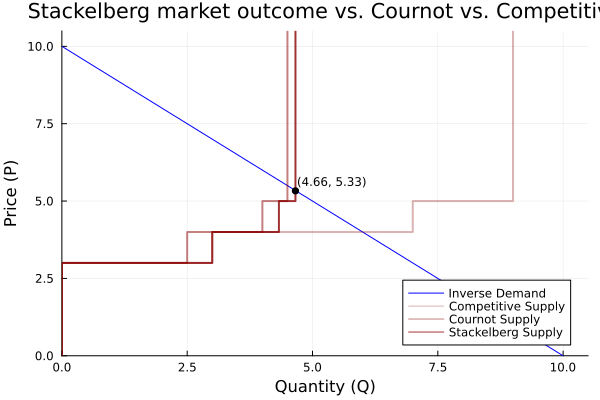

In [40]:
# Find optimal production quantities in Stackelberg model
q = optimal_production(mpec_model)
q_Cournot = optimal_production(cournot_model)

# Plot competitive supply curve
p = supply_demand_plot(c1, c2, c3, X1_max, X2_max, X3_max, firm_labels=false, alpha=0.3)

# Plot Cournot supply curve
supply_demand_plot(c1, c2, c3, q_Cournot[1], q_Cournot[2], q_Cournot[3], firm_labels=false, alpha=0.5, p=p)

# Plot Stackelberg supply curve
supply_demand_plot(c1, c2, c3, q[1], q[2], q[3], firm_labels=false,
                    title="Stackelberg market outcome vs. Cournot vs. Competitive",
                    equilibrium_point=true, Q=sum(q), P=market_price(mpec_model), p=p)

plot!(p, legend=:bottomright)
plot!(p, [], [], label="Inverse Demand", color=:blue)
plot!(p, [], [], label="Competitive Supply", color=:darkred, alpha=0.3)
plot!(p, [], [], label="Cournot Supply", color=:darkred, alpha=0.5)
plot!(p, [], [], label="Stackelberg Supply", color=:darkred, alpha=0.8)

### Task 3: Sensitivity analysis on leader's costs

Change the costs of firm 1 and observe how the market outcomes change. At what marginal cost does firm 1 stop producing? Is this cost higher than the costs of the competitors?

For reference, the marginal costs of the other firms are $c_2 = 4$ and $c_3 = 5$.

The solver found a OPTIMAL solution.
Market price: 5.33
Optimal production (x): [3.0, 1.33, 0.33]
Optimal profits: [7.0, 1.78, 0.11]
Social welfare: 19.78


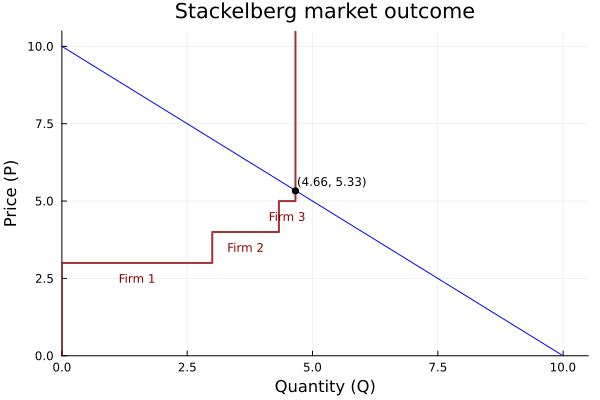

In [41]:
c1_new = 3
mpec_model_new = MPEC_firm1_leader_model(c1_new, c2, c3, X1_max, X2_max, X3_max)
println("Market price: ", market_price(mpec_model_new))
println("Optimal production (x): ", optimal_production(mpec_model_new))
println("Optimal profits: ", optimal_profits(mpec_model_new))
println("Social welfare: ", social_welfare(mpec_model_new))

q = optimal_production(mpec_model_new)

# Plot Stackelberg supply curve
supply_demand_plot(c1_new, c2, c3, q[1], q[2], q[3], firm_labels=true, title="Stackelberg market outcome",
                    equilibrium_point=true, Q=sum(q), P=market_price(mpec_model_new))

### Task 4 (EXTRA): Big-M reformulation

In the big-M variable transformation, a complementarity constraint of the form $$0 \leq x \perp F(x) \geq 0$$ is reformulated and results in the following constraints:

\begin{align*}
    & x \leq Mz \\
    & F(x) \leq M(1-z) \\
    & F(x) \geq 0 \\
    & x \geq 0 \\
    & z \in \{0, 1\}
\end{align*}

For firm 1's bilevel problem this would mean:

\begin{align}
    \min_{x_1, x_2, x_3} \quad & c_1 x_1 - \left( \alpha - \beta \sum_{i=1}^{3} x_i \right) x_1 \\
    \text{s.t.} \quad & x_1 - X_1^{\max} \leq 0 \\
    & -x_1 \leq 0 \\
    & \text{Lower-level problem:} \nonumber \\
    & \text{Nonnegativity:} \nonumber \\
    & 0 \leq x_i, \quad & i = 2, 3\\
    & 0 \leq c_i + \beta x_i - \alpha + \beta \sum_j x_j + \mu_i^{\max}, \quad & i = 2, 3\\
    & 0 \leq \mu_i^{\max}, \quad & i = 2, 3\\
    & 0 \leq X_i^{\max} - x_i, \quad & i = 2, 3\\
    & \text{Complementarity:} \nonumber \\
    & x_i \leq M z_i, \quad & i = 2, 3 \\
    & c_i + \beta x_i - \alpha + \beta \sum_j x_j + \mu_i^{\max} \leq M (1 - z_i), \quad & i = 2,3\\
    & \mu_i^{\max} \leq M y_i, \quad & i = 2, 3 \\
    & X_i^{\max} - x_i \leq M (1 - y_i), \quad & i = 2,3 \\
    & \text{Auxiliary variable definitions:} \nonumber \\
    & z_i, y_i \in \{0, 1\}, \quad & i = 2, 3
\end{align}

To solve this, we need a solver that can handle <span style="color:orange">**mixed-integer quadratic programs (MIQP)**</span> and we need to *choose* the big-M values. You can use **SCIP** for this as well.

*Hint:* You can create a single binary variable for a model `m` with `@variable(m, z, Bin)`.

In [ ]:
# Implement the big-M formulation here

# Define model


# Define parameters (remember big-M value)


# Define variables


# Define objective function


# Define top-level constraints


# Define lower-level KKT conditions


# Solve the model using the SCIP solver
